In [1]:
!pip install -q qiskit qiskit-ibm-provider qiskit_aer qiskit-ibm-runtime pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 115.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.9/249.9 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 121.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.3/111.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 5.2 MB/s et

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

In [3]:
cells = QuantumRegister(18, "cell")
enc = QuantumRegister(9,  "enc")
given = QuantumRegister(3,  "given")
cmp = QuantumRegister(3,  "cmp")
row = QuantumRegister(3,  "row")
col = QuantumRegister(3,  "col")
flags = QuantumRegister(3,  "flags")
phase = QuantumRegister(1,  "phase")

c = ClassicalRegister(18, "c")

In [4]:
def reg(cells, idx):
    """
    Returns the two qubits corresponding to Sudoku cell `idx`.
    """
    return cells[2 * idx], cells[2 * idx + 1]

In [5]:
def initialize_search_space(qc, cells):
    """
    Apply Hadamard gates to every search qubit,
    creating an equal superposition over all states.
    """
    qc.h(cells)

In [6]:
def initialize_phase_ancilla(qc, phase):
    """
    Prepare phase ancilla in |->
    """
    qc.x(phase[0])
    qc.h(phase[0])

In [7]:
def encoding_check(qc, cell_reg, anc):
    """
    anc = 1 if encoding is valid
        = 0 if encoding == 11

    cell_reg = (MSB, LSB)
    """

    msb, lsb = cell_reg

    qc.ccx(msb, lsb, anc)
    qc.x(anc)

In [8]:
def undo_encoding_check(qc, cell_reg, anc):
    """
    Reverse encoding_check().
    """

    msb, lsb = cell_reg

    qc.x(anc)
    qc.ccx(msb, lsb, anc)

In [9]:
def compare_registers(qc, regA, regB, cmp):
    """
    Compare two 2-qubit registers.

    cmp[0] : XNOR(MSB)
    cmp[1] : XNOR(LSB)
    cmp[2] : Equality flag

    Result:
        cmp[2] == 1 iff regA == regB
    """

    a1, a0 = regA
    b1, b0 = regB

    # Initialize XNOR ancillas
    qc.x(cmp[0])
    qc.x(cmp[1])

    # MSB XNOR
    qc.cx(a1, cmp[0])
    qc.cx(b1, cmp[0])

    # LSB XNOR
    qc.cx(a0, cmp[1])
    qc.cx(b0, cmp[1])

    # Equality
    qc.ccx(cmp[0], cmp[1], cmp[2])

In [10]:
def undo_compare_registers(qc, regA, regB, cmp):
    """
    Reverse compare_registers().
    """

    a1, a0 = regA
    b1, b0 = regB

    qc.ccx(cmp[0], cmp[1], cmp[2])

    qc.cx(b0, cmp[1])
    qc.cx(a0, cmp[1])

    qc.cx(b1, cmp[0])
    qc.cx(a1, cmp[0])

    qc.x(cmp[1])
    qc.x(cmp[0])

In [11]:
def compare_constant(qc, cell_reg, value, anc):
    """
    anc = 1 iff cell_reg == value

    value must be:
        0 -> 00
        1 -> 01
        2 -> 10
    """

    msb, lsb = cell_reg

    bits = {
        0: (0, 0),
        1: (0, 1),
        2: (1, 0)
    }[value]

    if bits[0] == 0:
        qc.x(msb)

    if bits[1] == 0:
        qc.x(lsb)

    qc.ccx(msb, lsb, anc)

    if bits[1] == 0:
        qc.x(lsb)

    if bits[0] == 0:
        qc.x(msb)

In [12]:
def undo_compare_constant(qc, cell_reg, value, anc):
    """
    Reverse compare_constant().

    Restores the cell qubits and ancilla to their original state.
    """

    msb, lsb = cell_reg

    bits = {
        0: (0, 0),
        1: (0, 1),
        2: (1, 0)
    }[value]

    # Reverse order of operations

    if bits[0] == 0:
        qc.x(msb)

    if bits[1] == 0:
        qc.x(lsb)

    qc.ccx(msb, lsb, anc)

    if bits[1] == 0:
        qc.x(lsb)

    if bits[0] == 0:
        qc.x(msb)

In [13]:
# A = QuantumRegister(2, "A")
# B = QuantumRegister(2, "B")
# cmp_test = QuantumRegister(3, "cmp")

# c_test = ClassicalRegister(7, "c")

# qc_test = QuantumCircuit(A, B, cmp_test, c_test)

In [14]:
# qc_test.x(A[0])
# qc_test.x(B[0])

In [15]:
# compare_registers(qc_test, A, B, cmp_test)
# qc_test.measure(A, c_test[0:2])
# qc_test.measure(B, c_test[2:4])
# qc_test.measure(cmp, c_test[4:7])
# qc_test.draw("mpl")

In [16]:
# cA = ClassicalRegister(2, "A_out")
# cB = ClassicalRegister(2, "B_out")
# cCmp = ClassicalRegister(3, "cmp_out")

# qc_test = QuantumCircuit(A, B, cmp, cA, cB, cCmp)
# qc_test.x(A[1])
# qc_test.x(B[0])
# compare_registers(qc_test, A, B, cmp_test)
# qc_test.measure(A, cA)
# qc_test.measure(B, cB)
# qc_test.measure(cmp, cCmp)
# qc_test.draw("mpl")

In [17]:
from qiskit_aer import AerSimulator

In [18]:
# sim = AerSimulator()

# result = sim.run(qc_test, shots=1024).result()

# counts = result.get_counts()

# print(counts)

In [19]:
qc = QuantumCircuit(
    cells,
    enc,
    given,
    cmp,
    row,
    col,
    flags,
    phase,
    c
)

In [20]:
def oracle(
    qc,
    cells,
    enc,
    given,
    cmp,
    row,
    col,
    flags,
    phase,
):
    qc.barrier()
    qc.barrier(*cells, *enc)
    for i in range(9):
        encoding_check(
            qc,
            reg(cells, i),
            enc[i]
        )
    qc.barrier(*cells, *enc)
    # for i in 

In [21]:
def oracle(
    qc,
    cells,
    enc,
    given,
    cmp,
    row,
    col,
    flags,
    phase,
):

    # ==================================================
    # Compute
    # ==================================================

    qc.barrier()

    # ---------------- Encoding Check ----------------

    qc.barrier(*cells, *enc)

    for i in range(9):
        encoding_check(
            qc,
            reg(cells, i),
            enc[i]
        )

    qc.barrier(*cells, *enc)

    # ---------------- Given Value Check ----------------

    qc.barrier(
        *reg(cells, 0),
        *reg(cells, 4),
        *reg(cells, 8),
        *given
    )

    compare_constant(
        qc,
        reg(cells, 0),
        0,
        given[0]
    )

    compare_constant(
        qc,
        reg(cells, 4),
        1,
        given[1]
    )

    compare_constant(
        qc,
        reg(cells, 8),
        2,
        given[2]
    )

    qc.barrier(
        *reg(cells, 0),
        *reg(cells, 4),
        *reg(cells, 8),
        *given
    )

    # ---------------- Row Constraints ----------------

    qc.barrier(*cells, *cmp, *row)

    # TODO : Row 0

    # TODO : Row 1

    # TODO : Row 2

    qc.barrier(*cells, *cmp, *row)

    # ---------------- Column Constraints ----------------

    qc.barrier(*cells, *cmp, *col)

    # TODO : Column 0

    # TODO : Column 1

    # TODO : Column 2

    qc.barrier(*cells, *cmp, *col)

    # ---------------- Global Constraint ----------------

    qc.barrier(*enc, *given, *row, *col, *flags)

    # TODO :
    # EncodingValid
    # GivenValid
    # RowValid
    # ColumnValid
    # -> flags[2]

    qc.barrier(*enc, *given, *row, *col, *flags)

    # ---------------- Phase Flip ----------------

    qc.barrier(*flags, *phase)

    # TODO :
    # Phase kickback using flags[2]

    qc.barrier(*flags, *phase)

    # ==================================================
    # Uncompute
    # ==================================================

    # ---------------- Undo Global Constraint ----------------

    qc.barrier(*enc, *given, *row, *col, *flags)

    # TODO

    qc.barrier(*enc, *given, *row, *col, *flags)

    # ---------------- Undo Column Constraints ----------------

    qc.barrier(*cells, *cmp, *col)

    # TODO : Column 2

    # TODO : Column 1

    # TODO : Column 0

    qc.barrier(*cells, *cmp, *col)

    # ---------------- Undo Row Constraints ----------------

    qc.barrier(*cells, *cmp, *row)

    # TODO : Row 2

    # TODO : Row 1

    # TODO : Row 0

    qc.barrier(*cells, *cmp, *row)

    # ---------------- Undo Given Value Check ----------------

    qc.barrier(
        *reg(cells, 0),
        *reg(cells, 4),
        *reg(cells, 8),
        *given
    )

    undo_compare_constant(
        qc,
        reg(cells, 8),
        2,
        given[2]
    )

    undo_compare_constant(
        qc,
        reg(cells, 4),
        1,
        given[1]
    )

    undo_compare_constant(
        qc,
        reg(cells, 0),
        0,
        given[0]
    )

    qc.barrier(
        *reg(cells, 0),
        *reg(cells, 4),
        *reg(cells, 8),
        *given
    )

    # ---------------- Undo Encoding Check ----------------

    qc.barrier(*cells, *enc)

    for i in reversed(range(9)):
        undo_encoding_check(
            qc,
            reg(cells, i),
            enc[i]
        )

    qc.barrier(*cells, *enc)

In [22]:
oracle(
    qc,
    cells,
    enc,
    given,
    cmp,
    row,
    col,
    flags,
    phase,
)

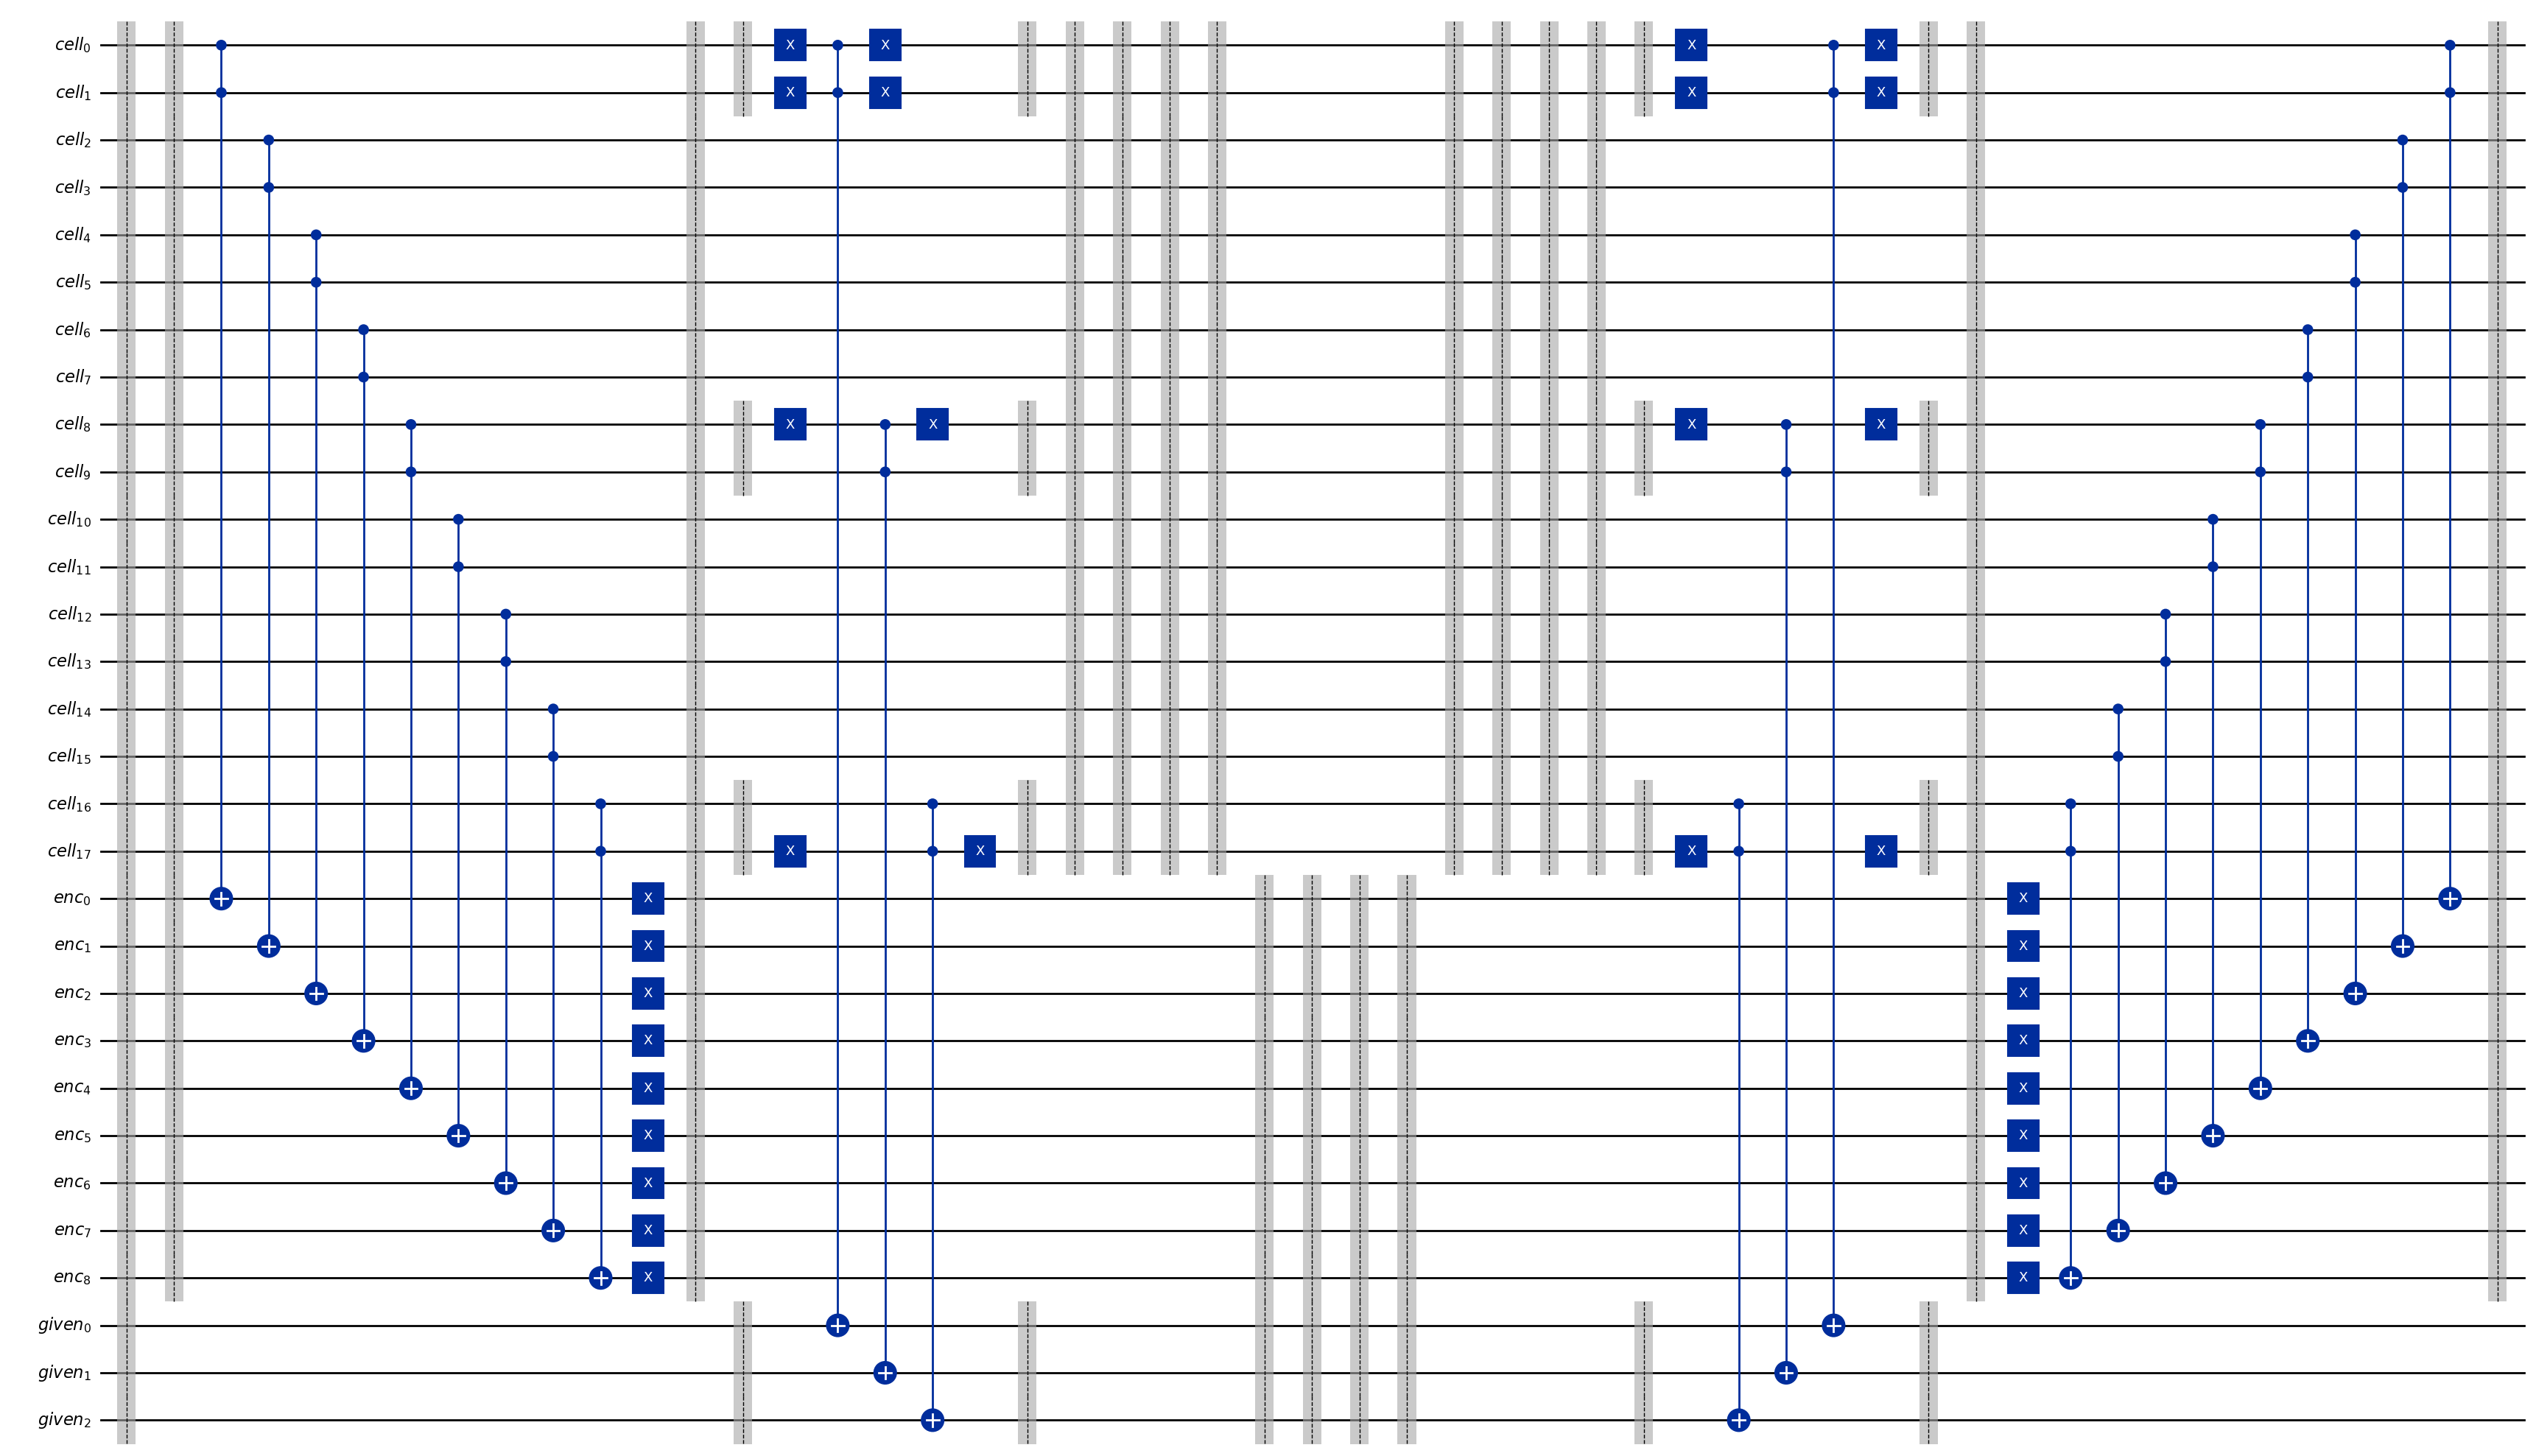

In [23]:
qc.draw(
    "mpl",
    idle_wires=False,
    fold=-1
)